# Heart-Rate Estimation from Wrist PPG During Motion (PPG-DaLiA)

The goal of this project is to estimate heart rate from wrist PPG during real-world activity. The dataset chosen is PPG-DaLiA, a 15-subject dataset with wrist and chest signal data. Accelerometer and PPG data are taken from the wrist, while the reference heart rate used in this study is pre-computed from a single-lead chest ECG.


## Setup

I used the directory structure provided with PPG-DaLiA. Set `PPG_DALIA_ROOT` to the `PPG_FieldStudy` directory if the dataset is stored somewhere else. Setting `RUN_CNN = True` reruns the full CNN LOSO experiment; otherwise the notebook uses the subject-level MAEs from my completed run.


In [1]:
from pathlib import Path
import json
import os
import pickle
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.signal import butter, filtfilt, find_peaks, medfilt

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Signal configuration from PPG-DaLiA
ACC_FS = 32
BVP_FS = 64
WIN_S = 8
SHIFT_S = 2
WA, SA = WIN_S * ACC_FS, SHIFT_S * ACC_FS
WB, SB = WIN_S * BVP_FS, SHIFT_S * BVP_FS
HR_BAND_HZ = (0.5, 4.0)

# Set this environment variable when the dataset lives elsewhere.
candidate_roots = [
    os.environ.get("PPG_DALIA_ROOT"),
    "../data/PPG_FieldStudy",
    "data/PPG_FieldStudy",
    "./PPG_FieldStudy",
]
DATA_ROOT = next(
    (Path(p).expanduser().resolve() for p in candidate_roots if p and Path(p).expanduser().exists()),
    None,
)

RUN_CNN = False
RESUME_CNN = True
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

CHECKPOINT_DIR = RESULTS_DIR / "checkpoints_nested"
PREDICTION_DIR = RESULTS_DIR / "predictions_nested"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

def subject_sort_key(subject_id):
    return int(subject_id.lstrip("S"))

print(f"Python {platform.python_version()} | NumPy {np.__version__} | SciPy {scipy.__version__}")
print("Dataset:", DATA_ROOT if DATA_ROOT else "not found — set PPG_DALIA_ROOT or update candidate_roots")
print("RUN_CNN:", RUN_CNN)


Python 3.12.3 | NumPy 2.2.4 | SciPy 1.15.2
Dataset: /home/ubuntu/ppg_dir/ppg-hr-estimation/data/PPG_FieldStudy
RUN_CNN: False


## Loading the data

I loaded each subject's wrist PPG and three-axis accelerometer signals along with the ECG-derived heart-rate labels. The checks below confirm that all 15 subject files are present before running the analysis.


In [2]:
def load_subject(path):
    with path.open("rb") as handle:
        return pickle.load(handle, encoding="latin1")

def require_dataset():
    if DATA_ROOT is None:
        raise FileNotFoundError(
            "PPG-DaLiA was not found. Set the PPG_DALIA_ROOT environment variable "
            "to the PPG_FieldStudy directory or edit candidate_roots in the setup cell."
        )

require_dataset()

subject_paths = sorted(DATA_ROOT.glob("S*/S*.pkl"), key=lambda p: subject_sort_key(p.stem))
if len(subject_paths) != 15:
    raise RuntimeError(f"Expected 15 subject files, found {len(subject_paths)} in {DATA_ROOT}")

subjects = {path.stem: load_subject(path) for path in subject_paths}

dataset_rows = []
for subject_id in sorted(subjects, key=subject_sort_key):
    d = subjects[subject_id]
    labels = np.asarray(d["label"], dtype=float)
    dataset_rows.append(
        {
            "subject": subject_id,
            "PPG samples": len(d["signal"]["wrist"]["BVP"]),
            "ACC samples": len(d["signal"]["wrist"]["ACC"]),
            "labels": len(labels),
            "HR min": labels.min(),
            "HR max": labels.max(),
        }
    )

dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)


,subject,PPG samples,ACC samples,labels,HR min,HR max
0,S1,589568,294784,4603,41.862467,150.154572
1,S2,525120,262560,4099,56.855197,149.248183
2,S3,559424,279712,4367,44.468146,148.717324
3,S4,585600,292800,4572,56.155672,131.990315
4,S5,595520,297760,4649,82.466318,187.015425
5,S6,336000,168000,2622,76.850122,174.315643
6,S7,597952,298976,4668,48.634693,152.913411
7,S8,517120,258560,4037,45.398975,115.502742
8,S9,547840,273920,4277,54.846064,154.277230
9,S10,681472,340736,5321,56.354167,146.372852


## Motion peaks within the heart-rate band

I divided the PPG and accelerometer signals for each subject into overlapping 8-second windows with a 2-second shift. For each window I then took the FFT of the signal. Peak detection was used to identify the dominant frequencies in the signals.

When pooling all of the accelerometer peaks across windows and subjects into a single distribution, I found that 68% of the peaks fell within the heart-rate frequency band of 0.5–4 Hz.


In [3]:
def pooled_accelerometer_peak_frequencies(subjects_dict):
    frequency_grid = np.fft.rfftfreq(WA, d=1 / ACC_FS)
    window = np.hanning(WA)
    pooled = []

    for d in subjects_dict.values():
        acceleration = np.asarray(d["signal"]["wrist"]["ACC"], dtype=float)
        magnitude = np.linalg.norm(acceleration, axis=1)
        magnitude -= magnitude.mean()

        n_windows = (len(magnitude) - WA) // SA + 1
        for i in range(n_windows):
            segment = magnitude[i * SA : i * SA + WA]
            spectrum = np.abs(np.fft.rfft(segment * window))
            peaks, _ = find_peaks(
                spectrum,
                height=spectrum.mean() + spectrum.std(),
                distance=2,
            )
            pooled.extend(frequency_grid[peaks])

    return np.asarray(pooled)

all_accel_peak_frequencies = pooled_accelerometer_peak_frequencies(subjects)
inside_hr_band = (
    (all_accel_peak_frequencies >= HR_BAND_HZ[0])
    & (all_accel_peak_frequencies <= HR_BAND_HZ[1])
)

print(f"Pooled accelerometer peaks: {len(all_accel_peak_frequencies):,}")
print(f"Peaks inside 0.5–4 Hz: {inside_hr_band.mean():.1%}")


Pooled accelerometer peaks: 265,206
Peaks inside 0.5–4 Hz: 68.0%


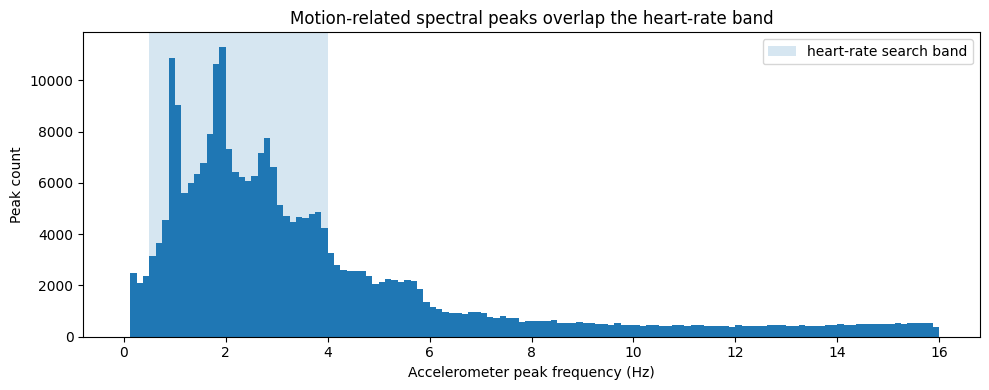

In [4]:
plt.figure(figsize=(10, 4))
plt.hist(all_accel_peak_frequencies, bins=np.arange(0, 16.125, 0.125))
plt.axvspan(*HR_BAND_HZ, alpha=0.18, label="heart-rate search band")
plt.xlabel("Accelerometer peak frequency (Hz)")
plt.ylabel("Peak count")
plt.title("Motion-related spectral peaks overlap the heart-rate band")
plt.legend()
plt.tight_layout()
plt.show()


## Method 1: Accelerometer-vetoed spectral peak detection

Starting with subject 1 (S1), I applied a spectral peak detector to the FFT of its windows and, for each window, picked the strongest PPG peak that was not near the accompanying accelerometer spectral peak or peaks. I then converted the frequency of that peak to heart rate and used median filtering to suppress isolated outlier estimates.

To apply the method across all subjects, I selected the accelerometer-veto tolerance and median-filter kernel using only the 14 training subjects in each LOSO fold.


In [5]:
KERNEL_SIZES = (7, 11, 15, 21)
VETO_TOLERANCES_HZ = (0.10, 0.15, 0.20)

def precompute_classical_features(d):
    acceleration = np.asarray(d["signal"]["wrist"]["ACC"], dtype=float)
    acceleration_magnitude = np.linalg.norm(acceleration, axis=1)
    acceleration_magnitude -= acceleration_magnitude.mean()

    acc_frequency_grid = np.fft.rfftfreq(WA, d=1 / ACC_FS)
    acc_window = np.hanning(WA)
    accelerometer_peaks = []

    n_acc_windows = (len(acceleration_magnitude) - WA) // SA + 1
    for i in range(n_acc_windows):
        segment = acceleration_magnitude[i * SA : i * SA + WA]
        spectrum = np.abs(np.fft.rfft(segment * acc_window))
        peaks, _ = find_peaks(spectrum, height=spectrum.mean() + spectrum.std())
        accelerometer_peaks.append(acc_frequency_grid[peaks])

    ppg = np.asarray(d["signal"]["wrist"]["BVP"], dtype=float).ravel()
    b, a = butter(4, HR_BAND_HZ, btype="bandpass", fs=BVP_FS)
    ppg = filtfilt(b, a, ppg)

    ppg_frequency_grid = np.fft.rfftfreq(WB, d=1 / BVP_FS)
    ppg_window = np.hanning(WB)
    ppg_peaks = []

    n_ppg_windows = (len(ppg) - WB) // SB + 1
    for i in range(n_ppg_windows):
        segment = ppg[i * SB : i * SB + WB]
        spectrum = np.abs(np.fft.rfft(segment * ppg_window))
        peaks, properties = find_peaks(spectrum, prominence=spectrum.std())
        order = np.argsort(properties["prominences"])[::-1]
        ppg_peaks.append(ppg_frequency_grid[peaks[order]])

    labels = np.asarray(d["label"], dtype=float)
    return {
        "accelerometer_peaks": accelerometer_peaks,
        "ppg_peaks": ppg_peaks,
        "labels": labels,
    }

def estimate_vetoed_peaks(cache, kernel_size, veto_tolerance_hz):
    n = min(
        len(cache["accelerometer_peaks"]),
        len(cache["ppg_peaks"]),
        len(cache["labels"]),
    )
    raw = np.full(n, np.nan)
    decision_info = []

    for i in range(n):
        motion_frequencies = cache["accelerometer_peaks"][i]
        ppg_candidates = cache["ppg_peaks"][i]

        selected_frequency = np.nan
        branch = "no_peaks"

        for frequency in ppg_candidates:
            overlaps_motion = np.any(np.abs(motion_frequencies - frequency) < veto_tolerance_hz)
            if not overlaps_motion:
                selected_frequency = frequency
                branch = "survivor"
                break

        if not np.isfinite(selected_frequency) and len(ppg_candidates):
            selected_frequency = ppg_candidates[0]
            branch = "fallback_all_vetoed"

        raw[i] = selected_frequency * 60 if np.isfinite(selected_frequency) else np.nan
        decision_info.append(
            {
                "branch": branch,
                "ppg_candidates": ppg_candidates,
                "motion_frequencies": motion_frequencies,
                "selected_frequency": selected_frequency,
            }
        )

    finite_raw = raw[np.isfinite(raw)]
    fill_value = np.median(finite_raw) if len(finite_raw) else 75.0
    filled_raw = np.where(np.isfinite(raw), raw, fill_value)

    smoothed = medfilt(filled_raw, kernel_size=kernel_size)
    truth = cache["labels"][:n]

    return {
        "raw": raw,
        "filled_raw": filled_raw,
        "smoothed": smoothed,
        "truth": truth,
        "decision_info": decision_info,
    }

CLASSICAL_CACHE = {
    subject_id: precompute_classical_features(d)
    for subject_id, d in subjects.items()
}
print("Cached classical features for", len(CLASSICAL_CACHE), "subjects")


Cached classical features for 15 subjects


In [6]:
def mean_absolute_error(prediction, truth):
    return float(np.mean(np.abs(np.asarray(prediction) - np.asarray(truth))))

parameter_grid = [
    (kernel_size, veto_tolerance)
    for kernel_size in KERNEL_SIZES
    for veto_tolerance in VETO_TOLERANCES_HZ
]

classical_loso = {}
for held_out in sorted(CLASSICAL_CACHE, key=subject_sort_key):
    training_subjects = [s for s in CLASSICAL_CACHE if s != held_out]

    def training_score(parameters):
        kernel_size, veto_tolerance = parameters
        subject_scores = []
        for subject_id in training_subjects:
            estimate = estimate_vetoed_peaks(
                CLASSICAL_CACHE[subject_id],
                kernel_size,
                veto_tolerance,
            )
            subject_scores.append(mean_absolute_error(estimate["smoothed"], estimate["truth"]))
        return np.mean(subject_scores)

    best_kernel, best_veto = min(parameter_grid, key=training_score)
    held_estimate = estimate_vetoed_peaks(
        CLASSICAL_CACHE[held_out],
        best_kernel,
        best_veto,
    )

    classical_loso[held_out] = {
        "mae": mean_absolute_error(held_estimate["smoothed"], held_estimate["truth"]),
        "kernel_size": best_kernel,
        "veto_tolerance_hz": best_veto,
        "estimate": held_estimate,
    }

classical_results = pd.DataFrame(
    [
        {
            "subject": subject_id,
            "MAE (bpm)": result["mae"],
            "median kernel": result["kernel_size"],
            "veto tolerance (Hz)": result["veto_tolerance_hz"],
        }
        for subject_id, result in classical_loso.items()
    ]
).sort_values("subject", key=lambda col: col.map(subject_sort_key))

classical_values = classical_results["MAE (bpm)"].to_numpy()
print(
    f"Classical LOSO MAE: {classical_values.mean():.2f} ± "
    f"{classical_values.std(ddof=0):.2f} bpm "
    f"(median subject {np.median(classical_values):.2f})"
)
display(classical_results.reset_index(drop=True))


Classical LOSO MAE: 13.01 ± 8.14 bpm (median subject 9.84)


,subject,MAE (bpm),median kernel,veto tolerance (Hz)
0,S1,7.167962,21,0.1
1,S2,9.418924,21,0.1
2,S3,10.241542,21,0.1
3,S4,15.290731,21,0.1
4,S5,39.478441,21,0.1
5,S6,17.737445,21,0.1
6,S7,4.791266,21,0.1
7,S8,9.788658,21,0.1
8,S9,17.633980,21,0.1
9,S10,9.842964,21,0.1


I then applied this technique to all subjects using an LOSO framework for proper cross-validation, achieving **13.0 ± 8.1 bpm MAE** with a median subject MAE of **9.8 bpm**. The ± value is the standard deviation across the 15 held-out subjects.


### S1 example

The trace below compares the raw spectral estimate, the median-filtered estimate, and the validated ECG-derived heart rate for S1.


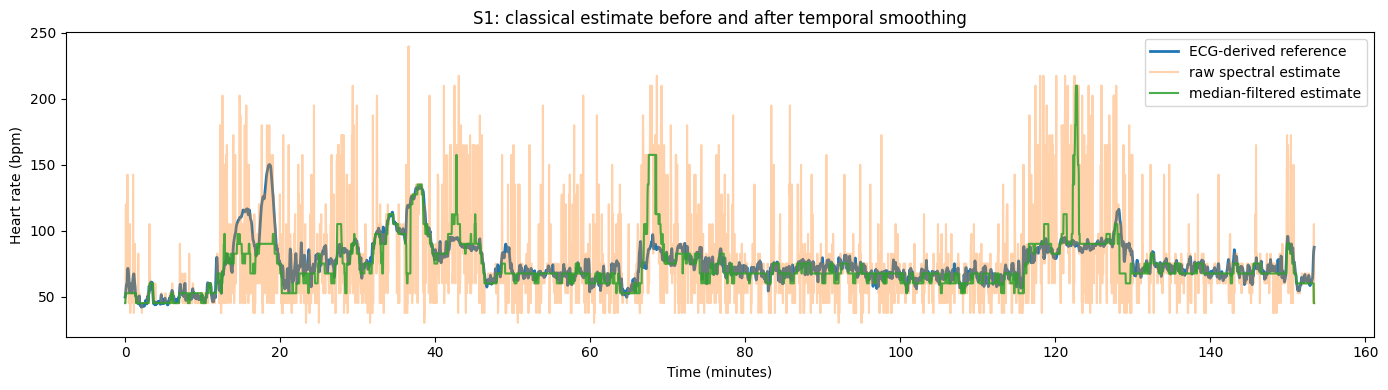

In [7]:
example_subject = "S1"
example = classical_loso[example_subject]["estimate"]
time_minutes = np.arange(len(example["truth"])) * SHIFT_S / 60

plt.figure(figsize=(14, 4))
plt.plot(time_minutes, example["truth"], linewidth=2, label="ECG-derived reference")
plt.plot(time_minutes, example["raw"], alpha=0.35, label="raw spectral estimate")
plt.plot(time_minutes, example["smoothed"], alpha=0.85, label="median-filtered estimate")
plt.xlabel("Time (minutes)")
plt.ylabel("Heart rate (bpm)")
plt.title(f"{example_subject}: classical estimate before and after temporal smoothing")
plt.legend()
plt.tight_layout()
plt.show()


## Failure analysis for Method 1

To understand where this method failed, I analyzed windows where the raw estimate was more than 10 bpm off before median filtering. I grouped each error according to whether the true PPG peak was absent, rejected as motion, or present but not selected because a stronger competing peak was chosen.

I then analyzed median filtering separately because the filtered value can be affected by neighboring windows rather than only the peak decision made in the current window.


In [8]:
RAW_ERROR_THRESHOLD_BPM = 10
TRUE_PEAK_TOLERANCE_HZ = 0.10

def classify_raw_failures(estimate, veto_tolerance_hz):
    counts = {
        "no PPG peaks": 0,
        "all candidates vetoed": 0,
        "true-frequency peak absent": 0,
        "true-frequency peak vetoed": 0,
        "competing peak selected": 0,
    }

    for i, info in enumerate(estimate["decision_info"]):
        raw_value = estimate["raw"][i]
        truth = estimate["truth"][i]
        is_bad = (not np.isfinite(raw_value)) or abs(raw_value - truth) > RAW_ERROR_THRESHOLD_BPM
        if not is_bad:
            continue

        candidates = info["ppg_candidates"]
        motion_frequencies = info["motion_frequencies"]
        true_frequency = truth / 60

        if len(candidates) == 0:
            counts["no PPG peaks"] += 1
            continue

        if info["branch"] == "fallback_all_vetoed":
            counts["all candidates vetoed"] += 1
            continue

        true_peak_exists = np.any(np.abs(candidates - true_frequency) < TRUE_PEAK_TOLERANCE_HZ)
        if not true_peak_exists:
            counts["true-frequency peak absent"] += 1
            continue

        true_peak_overlaps_motion = np.any(
            np.abs(motion_frequencies - true_frequency) < veto_tolerance_hz
        )
        if true_peak_overlaps_motion:
            counts["true-frequency peak vetoed"] += 1
        else:
            counts["competing peak selected"] += 1

    return counts

def smoothing_transitions(estimate):
    raw_bad = (~np.isfinite(estimate["raw"])) | (
        np.abs(estimate["raw"] - estimate["truth"]) > RAW_ERROR_THRESHOLD_BPM
    )
    smooth_bad = (
        np.abs(estimate["smoothed"] - estimate["truth"]) > RAW_ERROR_THRESHOLD_BPM
    )

    return {
        "correct before and after": int(np.sum(~raw_bad & ~smooth_bad)),
        "corrected by smoothing": int(np.sum(raw_bad & ~smooth_bad)),
        "introduced by smoothing": int(np.sum(~raw_bad & smooth_bad)),
        "incorrect before and after": int(np.sum(raw_bad & smooth_bad)),
    }

raw_failure_total = {}
smoothing_total = {}

for subject_id, result in classical_loso.items():
    raw_counts = classify_raw_failures(
        result["estimate"],
        result["veto_tolerance_hz"],
    )
    smooth_counts = smoothing_transitions(result["estimate"])

    for name, value in raw_counts.items():
        raw_failure_total[name] = raw_failure_total.get(name, 0) + value
    for name, value in smooth_counts.items():
        smoothing_total[name] = smoothing_total.get(name, 0) + value

raw_failure_df = pd.DataFrame(
    {"failure mechanism": raw_failure_total.keys(), "windows": raw_failure_total.values()}
)
raw_failure_df["share of raw failures"] = (
    raw_failure_df["windows"] / raw_failure_df["windows"].sum()
)

smoothing_df = pd.DataFrame(
    {"transition": smoothing_total.keys(), "windows": smoothing_total.values()}
)
smoothing_df["share of all windows"] = smoothing_df["windows"] / smoothing_df["windows"].sum()

display(raw_failure_df.sort_values("windows", ascending=False).reset_index(drop=True))
display(smoothing_df.reset_index(drop=True))


,failure mechanism,windows,share of raw failures
0,true-frequency peak absent,13167,0.495168
1,competing peak selected,7365,0.276973
2,true-frequency peak vetoed,5664,0.213004
3,all candidates vetoed,395,0.014855
4,no PPG peaks,0,0.000000


,transition,windows,share of all windows
0,correct before and after,32506,0.502434
1,corrected by smoothing,11835,0.182930
2,introduced by smoothing,5600,0.086557
3,incorrect before and after,14756,0.228079


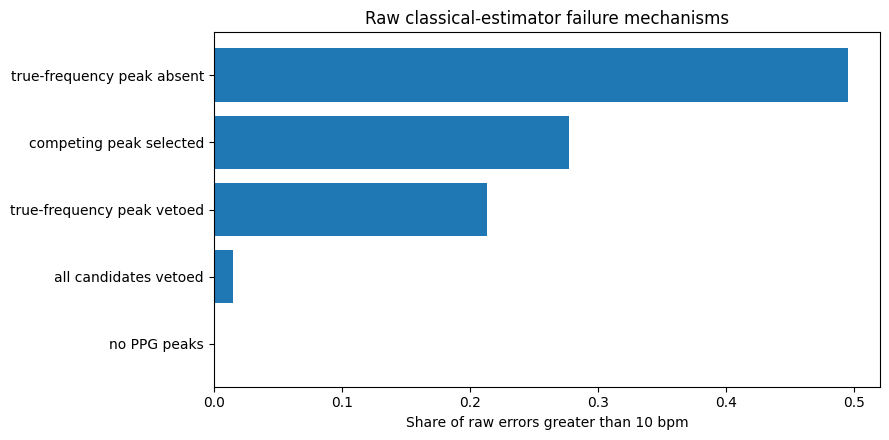

In [9]:
failure_plot = raw_failure_df.sort_values("windows")
plt.figure(figsize=(9, 4.5))
plt.barh(failure_plot["failure mechanism"], failure_plot["share of raw failures"])
plt.xlabel("Share of raw errors greater than 10 bpm")
plt.title("Raw classical-estimator failure mechanisms")
plt.tight_layout()
plt.show()


## Motion-spectrum subtraction

To improve the classical result, I tried a simplified SpaMaPlus-style spectral subtraction approach taken from the literature. This approach subtracts the scaled accelerometer spectrum from the PPG spectrum using

$$
S_{\mathrm{clean}} = S_{\mathrm{PPG}} - \alpha S_{\mathrm{accel}}
$$

where $\alpha$ is chosen to minimize the mean MAE across the training subjects during each LOSO fold.


In [10]:
SPECTRAL_ALPHAS = (0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0)
SPECTRAL_KERNEL = 21

def precompute_spectral_subtraction(d):
    ppg = np.asarray(d["signal"]["wrist"]["BVP"], dtype=float).ravel()
    b, a = butter(4, HR_BAND_HZ, btype="bandpass", fs=BVP_FS)
    ppg = filtfilt(b, a, ppg)

    acceleration = np.asarray(d["signal"]["wrist"]["ACC"], dtype=float)
    acceleration_magnitude = np.linalg.norm(acceleration, axis=1)
    acceleration_magnitude -= acceleration_magnitude.mean()

    ppg_frequency_grid = np.fft.rfftfreq(WB, d=1 / BVP_FS)
    acc_frequency_grid = np.fft.rfftfreq(WA, d=1 / ACC_FS)
    ppg_window = np.hanning(WB)
    acc_window = np.hanning(WA)

    n = min(
        (len(ppg) - WB) // SB + 1,
        (len(acceleration_magnitude) - WA) // SA + 1,
        len(d["label"]),
    )

    ppg_spectra = []
    acc_spectra = []
    for i in range(n):
        ppg_segment = ppg[i * SB : i * SB + WB]
        acc_segment = acceleration_magnitude[i * SA : i * SA + WA]

        ppg_spectrum = np.abs(np.fft.rfft(ppg_segment * ppg_window))
        acc_spectrum = np.abs(np.fft.rfft(acc_segment * acc_window))
        acc_on_ppg_grid = np.interp(
            ppg_frequency_grid,
            acc_frequency_grid,
            acc_spectrum,
            right=0.0,
        )

        if acc_on_ppg_grid.max() > 0:
            acc_on_ppg_grid *= ppg_spectrum.max() / acc_on_ppg_grid.max()

        ppg_spectra.append(ppg_spectrum)
        acc_spectra.append(acc_on_ppg_grid)

    return {
        "frequency_grid": ppg_frequency_grid,
        "ppg_spectra": np.asarray(ppg_spectra),
        "acc_spectra": np.asarray(acc_spectra),
        "labels": np.asarray(d["label"][:n], dtype=float),
        "age": d.get("questionnaire", {}).get("AGE", None),
    }

def estimate_spectral_subtraction(cache, alpha):
    frequency_grid = cache["frequency_grid"]
    labels = cache["labels"]
    age = cache["age"]
    maximum_hr = 220 - age if age else 200

    physiological_mask = (
        (frequency_grid * 60 >= 40)
        & (frequency_grid * 60 <= maximum_hr)
    )

    raw = np.full(len(labels), np.nan)
    for i, (ppg_spectrum, acc_spectrum) in enumerate(
        zip(cache["ppg_spectra"], cache["acc_spectra"])
    ):
        cleaned = np.clip(ppg_spectrum - alpha * acc_spectrum, 0, None)
        cleaned = cleaned * physiological_mask

        peaks, _ = find_peaks(cleaned, prominence=cleaned.std())
        if len(peaks):
            selected_bin = peaks[np.argmax(cleaned[peaks])]
        elif cleaned.max() > 0:
            selected_bin = int(np.argmax(cleaned))
        else:
            continue

        raw[i] = frequency_grid[selected_bin] * 60

    finite_raw = raw[np.isfinite(raw)]
    fill_value = np.median(finite_raw) if len(finite_raw) else 75.0
    filled = np.where(np.isfinite(raw), raw, fill_value)
    smoothed = medfilt(filled, kernel_size=SPECTRAL_KERNEL)
    return {"raw": raw, "smoothed": smoothed, "truth": labels}

SPECTRAL_CACHE = {
    subject_id: precompute_spectral_subtraction(d)
    for subject_id, d in subjects.items()
}

spectral_score_table = {
    subject_id: {
        alpha: mean_absolute_error(
            estimate_spectral_subtraction(cache, alpha)["smoothed"],
            cache["labels"],
        )
        for alpha in SPECTRAL_ALPHAS
    }
    for subject_id, cache in SPECTRAL_CACHE.items()
}

spectral_loso = {}
for held_out in sorted(SPECTRAL_CACHE, key=subject_sort_key):
    training_subjects = [s for s in SPECTRAL_CACHE if s != held_out]
    best_alpha = min(
        SPECTRAL_ALPHAS,
        key=lambda alpha: np.mean(
            [spectral_score_table[s][alpha] for s in training_subjects]
        ),
    )

    estimate = estimate_spectral_subtraction(SPECTRAL_CACHE[held_out], best_alpha)
    spectral_loso[held_out] = {
        "mae": mean_absolute_error(estimate["smoothed"], estimate["truth"]),
        "alpha": best_alpha,
        "estimate": estimate,
    }

spectral_results = pd.DataFrame(
    [
        {"subject": subject_id, "MAE (bpm)": result["mae"], "alpha": result["alpha"]}
        for subject_id, result in spectral_loso.items()
    ]
).sort_values("subject", key=lambda col: col.map(subject_sort_key))

spectral_values = spectral_results["MAE (bpm)"].to_numpy()
print(
    f"Spectral-subtraction LOSO MAE: {spectral_values.mean():.2f} ± "
    f"{spectral_values.std(ddof=0):.2f} bpm "
    f"(median subject {np.median(spectral_values):.2f})"
)
display(spectral_results.reset_index(drop=True))


Spectral-subtraction LOSO MAE: 12.94 ± 7.84 bpm (median subject 10.10)


,subject,MAE (bpm),alpha
0,S1,7.101092,2.0
1,S2,9.602876,2.0
2,S3,10.048986,2.0
3,S4,14.633400,2.0
4,S5,39.415757,2.0
5,S6,16.331368,2.0
6,S7,5.907537,2.0
7,S8,9.496642,2.0
8,S9,14.651642,2.0
9,S10,11.184801,2.0


This approach tied the first baseline, achieving **12.9 ± 7.8 bpm MAE** with a median subject MAE of **10.1 bpm**. LOSO tuning consistently selected the largest tested $\alpha$, showing that removing more accelerometer spectral energy produced better training-subject performance within this implementation.


## 1D CNN

I then trained a 1D CNN using four standardized time-domain channels: PPG and the three accelerometer axes. Each window contained 8 seconds of data and the outer evaluation remained LOSO, with one subject held out for testing in each fold.

For each outer fold, I used two of the remaining subjects as an inner validation set. The validation subjects were used to choose the number of training epochs through early stopping. I then initialized a new model, retrained it on all 14 non-test subjects for the selected number of epochs, and evaluated it once on the held-out subject. This prevents the held-out subject from influencing model selection while still allowing the final fold model to use all available training subjects.

Each outer fold saves its final model weights, target normalization, subject split, seed, selected epoch, validation history, and training configuration.

In [11]:
def assemble_time_domain_windows(d):
    ppg = np.asarray(d["signal"]["wrist"]["BVP"], dtype=float).ravel()
    acceleration = np.asarray(d["signal"]["wrist"]["ACC"], dtype=float)
    labels = np.asarray(d["label"], dtype=np.float32)

    acc_time = np.arange(len(acceleration)) / ACC_FS
    ppg_time = np.arange(len(ppg)) / BVP_FS
    acceleration_upsampled = np.stack(
        [
            np.interp(ppg_time, acc_time, acceleration[:, channel])
            for channel in range(3)
        ],
        axis=1,
    )

    n = min((len(ppg) - WB) // SB + 1, len(labels))
    X = np.empty((n, 4, WB), dtype=np.float32)

    for i in range(n):
        start = i * SB
        channels = np.vstack(
            [
                ppg[start : start + WB],
                acceleration_upsampled[start : start + WB].T,
            ]
        )
        channel_mean = channels.mean(axis=1, keepdims=True)
        channel_std = channels.std(axis=1, keepdims=True)
        X[i] = (channels - channel_mean) / (channel_std + 1e-8)

    return X, labels[:n]

TIME_DOMAIN_DATA = {
    subject_id: assemble_time_domain_windows(d)
    for subject_id, d in subjects.items()
}

window_summary = pd.DataFrame(
    [
        {
            "subject": subject_id,
            "windows": X.shape[0],
            "channels": X.shape[1],
            "samples/window": X.shape[2],
            "HR min": float(y.min()),
            "HR max": float(y.max()),
        }
        for subject_id, (X, y) in TIME_DOMAIN_DATA.items()
    ]
).sort_values("subject", key=lambda col: col.map(subject_sort_key))

display(window_summary.reset_index(drop=True))


,subject,windows,channels,samples/window,HR min,HR max
0,S1,4603,4,512,41.862469,150.154572
1,S2,4099,4,512,56.855198,149.248184
2,S3,4367,4,512,44.468147,148.717331
3,S4,4572,4,512,56.155674,131.990311
4,S5,4649,4,512,82.466316,187.015427
5,S6,2622,4,512,76.850121,174.315643
6,S7,4668,4,512,48.634693,152.913406
7,S8,4037,4,512,45.398975,115.502739
8,S9,4277,4,512,54.846066,154.277237
9,S10,5321,4,512,56.354168,146.372849


In [12]:
# Importing PyTorch here keeps the classical sections usable without it.
import copy

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ask PyTorch for deterministic behavior where supported.
torch.use_deterministic_algorithms(True, warn_only=True)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")


class HeartRateCNN(nn.Module):
    def __init__(self, input_channels=4):
        super().__init__()

        def block(in_channels, out_channels, kernel_size):
            return nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size,
                    padding=kernel_size // 2,
                ),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.MaxPool1d(2),
            )

        self.features = nn.Sequential(
            block(input_channels, 32, 7),
            block(32, 64, 5),
            block(64, 128, 5),
            block(128, 128, 3),
            nn.AdaptiveAvgPool1d(1),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(-1)


CNN_MODEL_CONFIG = {
    "input_channels": 4,
    "convolution_channels": [32, 64, 128, 128],
    "kernel_sizes": [7, 5, 5, 3],
    "dropout": 0.30,
}

CNN_TRAINING_CONFIG = {
    "maximum_inner_epochs": 40,
    "minimum_inner_epochs": 8,
    "early_stopping_patience": 6,
    "early_stopping_min_delta_bpm": 0.02,
    "inner_validation_subjects": 2,
    "batch_size": 512,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "loss": "SmoothL1Loss",
    "smooth_l1_beta": 0.5,
    "scheduler_factor": 0.5,
    "scheduler_patience": 2,
}


def concatenate_subjects(subject_ids):
    X = np.concatenate(
        [TIME_DOMAIN_DATA[subject_id][0] for subject_id in subject_ids]
    ).astype(np.float32)
    y = np.concatenate(
        [TIME_DOMAIN_DATA[subject_id][1] for subject_id in subject_ids]
    ).astype(np.float32)
    return X, y


def make_training_loader(
    subject_ids,
    target_mean,
    target_std,
    batch_size,
    seed,
):
    X, y = concatenate_subjects(subject_ids)
    y_standardized = (y - target_mean) / target_std

    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        TensorDataset(
            torch.from_numpy(X),
            torch.from_numpy(y_standardized),
        ),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
    )


def predict_subject(model, subject_id, target_mean, target_std):
    X, truth = TIME_DOMAIN_DATA[subject_id]

    model.eval()
    predictions = []

    with torch.no_grad():
        for start in range(0, len(X), CNN_TRAINING_CONFIG["batch_size"]):
            X_batch = torch.from_numpy(
                X[start : start + CNN_TRAINING_CONFIG["batch_size"]]
            ).to(DEVICE)
            standardized_prediction = model(X_batch).cpu().numpy()
            predictions.append(standardized_prediction)

    standardized_prediction = np.concatenate(predictions)
    prediction = standardized_prediction * target_std + target_mean

    return prediction.astype(np.float32), truth.astype(np.float32)


def train_one_epoch(model, loader, optimizer, loss_function):
    model.train()
    batch_losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = loss_function(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(float(loss.detach().cpu()))

    return float(np.mean(batch_losses))


def choose_inner_validation_subjects(outer_training_subjects, fold_seed):
    rng = np.random.default_rng(fold_seed)
    validation_subjects = rng.choice(
        outer_training_subjects,
        size=CNN_TRAINING_CONFIG["inner_validation_subjects"],
        replace=False,
    ).tolist()

    return sorted(validation_subjects, key=subject_sort_key)


def select_training_epoch(
    optimization_subjects,
    validation_subjects,
    fold_seed,
):
    random.seed(fold_seed)
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(fold_seed)

    _, optimization_targets = concatenate_subjects(optimization_subjects)
    target_mean = float(optimization_targets.mean())
    target_std = float(optimization_targets.std())

    loader = make_training_loader(
        subject_ids=optimization_subjects,
        target_mean=target_mean,
        target_std=target_std,
        batch_size=CNN_TRAINING_CONFIG["batch_size"],
        seed=fold_seed,
    )

    model = HeartRateCNN(
        input_channels=CNN_MODEL_CONFIG["input_channels"]
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CNN_TRAINING_CONFIG["learning_rate"],
        weight_decay=CNN_TRAINING_CONFIG["weight_decay"],
    )
    loss_function = nn.SmoothL1Loss(
        beta=CNN_TRAINING_CONFIG["smooth_l1_beta"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=CNN_TRAINING_CONFIG["scheduler_factor"],
        patience=CNN_TRAINING_CONFIG["scheduler_patience"],
    )

    best_epoch = 1
    best_validation_mae = float("inf")
    epochs_without_improvement = 0
    history = []

    for epoch in range(
        1,
        CNN_TRAINING_CONFIG["maximum_inner_epochs"] + 1,
    ):
        training_loss = train_one_epoch(
            model=model,
            loader=loader,
            optimizer=optimizer,
            loss_function=loss_function,
        )

        validation_mae_by_subject = {}
        for subject_id in validation_subjects:
            prediction, truth = predict_subject(
                model=model,
                subject_id=subject_id,
                target_mean=target_mean,
                target_std=target_std,
            )
            validation_mae_by_subject[subject_id] = mean_absolute_error(
                prediction,
                truth,
            )

        # Equal subject weighting prevents a subject with more windows from
        # dominating the model-selection metric.
        validation_mae = float(
            np.mean(list(validation_mae_by_subject.values()))
        )
        scheduler.step(validation_mae)

        current_learning_rate = float(
            optimizer.param_groups[0]["lr"]
        )
        history.append(
            {
                "epoch": epoch,
                "training_loss": training_loss,
                "validation_mae_bpm": validation_mae,
                "validation_mae_by_subject": validation_mae_by_subject,
                "learning_rate": current_learning_rate,
            }
        )

        improved = (
            validation_mae
            < best_validation_mae
            - CNN_TRAINING_CONFIG["early_stopping_min_delta_bpm"]
        )

        if improved:
            best_validation_mae = validation_mae
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epoch >= CNN_TRAINING_CONFIG["minimum_inner_epochs"]
            and epochs_without_improvement
            >= CNN_TRAINING_CONFIG["early_stopping_patience"]
        ):
            break

    return {
        "best_epoch": int(best_epoch),
        "best_validation_mae_bpm": float(best_validation_mae),
        "history": history,
        "optimization_target_mean": target_mean,
        "optimization_target_std": target_std,
    }


def train_final_outer_fold(
    outer_training_subjects,
    held_out_subject,
    selected_epochs,
    fold_seed,
    checkpoint_path,
):
    final_seed = fold_seed + 10_000
    random.seed(final_seed)
    np.random.seed(final_seed)
    torch.manual_seed(final_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(final_seed)

    _, training_targets = concatenate_subjects(outer_training_subjects)
    target_mean = float(training_targets.mean())
    target_std = float(training_targets.std())

    loader = make_training_loader(
        subject_ids=outer_training_subjects,
        target_mean=target_mean,
        target_std=target_std,
        batch_size=CNN_TRAINING_CONFIG["batch_size"],
        seed=final_seed,
    )

    model = HeartRateCNN(
        input_channels=CNN_MODEL_CONFIG["input_channels"]
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CNN_TRAINING_CONFIG["learning_rate"],
        weight_decay=CNN_TRAINING_CONFIG["weight_decay"],
    )
    loss_function = nn.SmoothL1Loss(
        beta=CNN_TRAINING_CONFIG["smooth_l1_beta"]
    )

    epoch_training_loss = []
    for _ in range(selected_epochs):
        epoch_training_loss.append(
            train_one_epoch(
                model=model,
                loader=loader,
                optimizer=optimizer,
                loss_function=loss_function,
            )
        )

    prediction, truth = predict_subject(
        model=model,
        subject_id=held_out_subject,
        target_mean=target_mean,
        target_std=target_std,
    )
    fold_mae = mean_absolute_error(prediction, truth)

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    cpu_state_dict = {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
    }

    return {
        "model": model,
        "model_state_dict": cpu_state_dict,
        "prediction": prediction,
        "truth": truth,
        "mae": fold_mae,
        "target_mean": target_mean,
        "target_std": target_std,
        "final_seed": final_seed,
        "epoch_training_loss": epoch_training_loss,
    }


def load_cnn_checkpoint(checkpoint_path, device="cpu"):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=torch.device(device),
    )

    model = HeartRateCNN(
        input_channels=checkpoint["model_config"]["input_channels"]
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return model, checkpoint


print("PyTorch", torch.__version__, "| device:", DEVICE)


/home/ubuntu/icentia/dev/icentiadev/lib/python3.12/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


PyTorch 2.13.0+cu130 | device: cpu


In [13]:
# These values are retained only as a clearly labeled historical comparison
# when a nested-training run has not yet been completed.
ORIGINAL_SINGLE_RUN_CNN_MAE = {
    "S1": 5.8,
    "S2": 5.5,
    "S3": 4.0,
    "S4": 6.9,
    "S5": 18.4,
    "S6": 7.5,
    "S7": 3.6,
    "S8": 16.6,
    "S9": 10.8,
    "S10": 5.1,
    "S11": 8.5,
    "S12": 8.3,
    "S13": 4.2,
    "S14": 4.8,
    "S15": 5.4,
}

NESTED_MAE_PATH = RESULTS_DIR / "cnn_nested_mae.json"
NESTED_MANIFEST_PATH = RESULTS_DIR / "cnn_nested_manifest.json"

cnn_predictions = {}
cnn_mae = {}
checkpoint_manifest = {}

if RUN_CNN:
    ordered_subjects = sorted(
        TIME_DOMAIN_DATA,
        key=subject_sort_key,
    )

    if RESUME_CNN and NESTED_MANIFEST_PATH.exists():
        with NESTED_MANIFEST_PATH.open() as handle:
            checkpoint_manifest = json.load(handle)

    for fold_index, held_out_subject in enumerate(
        ordered_subjects,
        start=1,
    ):
        fold_start_time = time.time()
        checkpoint_path = (
            CHECKPOINT_DIR / f"cnn_{held_out_subject}.pt"
        )
        prediction_path = (
            PREDICTION_DIR / f"cnn_{held_out_subject}.npz"
        )

        if (
            RESUME_CNN
            and checkpoint_path.exists()
            and prediction_path.exists()
        ):
            saved_prediction = np.load(prediction_path)
            prediction = saved_prediction["prediction"]
            truth = saved_prediction["truth"]
            fold_mae = mean_absolute_error(prediction, truth)

            cnn_predictions[held_out_subject] = {
                "prediction": prediction,
                "truth": truth,
                "mae": fold_mae,
                "checkpoint_path": str(checkpoint_path),
            }
            cnn_mae[held_out_subject] = fold_mae

            print(
                f"[{fold_index:02d}/15] {held_out_subject}: "
                f"{fold_mae:.2f} bpm | resumed"
            )
            continue

        outer_training_subjects = [
            subject_id
            for subject_id in ordered_subjects
            if subject_id != held_out_subject
        ]

        fold_seed = SEED + fold_index
        validation_subjects = choose_inner_validation_subjects(
            outer_training_subjects=outer_training_subjects,
            fold_seed=fold_seed,
        )
        optimization_subjects = [
            subject_id
            for subject_id in outer_training_subjects
            if subject_id not in validation_subjects
        ]

        epoch_selection = select_training_epoch(
            optimization_subjects=optimization_subjects,
            validation_subjects=validation_subjects,
            fold_seed=fold_seed,
        )

        final_result = train_final_outer_fold(
            outer_training_subjects=outer_training_subjects,
            held_out_subject=held_out_subject,
            selected_epochs=epoch_selection["best_epoch"],
            fold_seed=fold_seed,
            checkpoint_path=checkpoint_path,
        )

        checkpoint = {
            "model_state_dict": final_result["model_state_dict"],
            "held_out_subject": held_out_subject,
            "outer_training_subjects": outer_training_subjects,
            "inner_optimization_subjects": optimization_subjects,
            "inner_validation_subjects": validation_subjects,
            "fold_seed": fold_seed,
            "final_training_seed": final_result["final_seed"],
            "selected_epochs": epoch_selection["best_epoch"],
            "best_inner_validation_mae_bpm": (
                epoch_selection["best_validation_mae_bpm"]
            ),
            "inner_validation_history": epoch_selection["history"],
            "target_mean": final_result["target_mean"],
            "target_std": final_result["target_std"],
            "held_out_mae_bpm": final_result["mae"],
            "final_epoch_training_loss": (
                final_result["epoch_training_loss"]
            ),
            "model_config": CNN_MODEL_CONFIG,
            "training_config": CNN_TRAINING_CONFIG,
            "preprocessing_config": {
                "ppg_sampling_rate_hz": BVP_FS,
                "accelerometer_sampling_rate_hz": ACC_FS,
                "window_seconds": WIN_S,
                "shift_seconds": SHIFT_S,
                "samples_per_window": WB,
                "input_channels": [
                    "PPG",
                    "accelerometer_x",
                    "accelerometer_y",
                    "accelerometer_z",
                ],
                "accelerometer_resampling": (
                    "linear interpolation to PPG timestamps"
                ),
                "input_normalization": (
                    "per-window, per-channel z-score"
                ),
                "target_normalization": (
                    "outer-training-fold mean and standard deviation"
                ),
            },
            "software_versions": {
                "python": platform.python_version(),
                "numpy": np.__version__,
                "torch": torch.__version__,
            },
        }
        torch.save(checkpoint, checkpoint_path)

        np.savez_compressed(
            prediction_path,
            prediction=final_result["prediction"],
            truth=final_result["truth"],
        )

        cnn_predictions[held_out_subject] = {
            "prediction": final_result["prediction"],
            "truth": final_result["truth"],
            "mae": final_result["mae"],
            "checkpoint_path": str(checkpoint_path),
        }
        cnn_mae[held_out_subject] = final_result["mae"]

        checkpoint_manifest[held_out_subject] = {
            "checkpoint": str(checkpoint_path),
            "prediction_file": str(prediction_path),
            "held_out_subject": held_out_subject,
            "outer_training_subjects": outer_training_subjects,
            "inner_optimization_subjects": optimization_subjects,
            "inner_validation_subjects": validation_subjects,
            "fold_seed": fold_seed,
            "final_training_seed": final_result["final_seed"],
            "selected_epochs": epoch_selection["best_epoch"],
            "best_inner_validation_mae_bpm": (
                epoch_selection["best_validation_mae_bpm"]
            ),
            "target_mean": final_result["target_mean"],
            "target_std": final_result["target_std"],
            "held_out_mae_bpm": final_result["mae"],
        }

        # Save progress after every fold.
        with NESTED_MANIFEST_PATH.open("w") as handle:
            json.dump(checkpoint_manifest, handle, indent=2)

        with NESTED_MAE_PATH.open("w") as handle:
            json.dump(cnn_mae, handle, indent=2)

        print(
            f"[{fold_index:02d}/15] {held_out_subject}: "
            f"{final_result['mae']:.2f} bpm | "
            f"selected {epoch_selection['best_epoch']} epochs | "
            f"validation {epoch_selection['best_validation_mae_bpm']:.2f} bpm | "
            f"saved {checkpoint_path.name} | "
            f"{time.time() - fold_start_time:.0f} s"
        )

    # Aggregate prediction arrays for the downstream trace cell.
    np.savez_compressed(
        RESULTS_DIR / "cnn_nested_predictions.npz",
        **{
            f"{subject_id}_{array_name}": fold[array_name]
            for subject_id, fold in cnn_predictions.items()
            for array_name in ("prediction", "truth")
        },
    )

elif NESTED_MAE_PATH.exists():
    with NESTED_MAE_PATH.open() as handle:
        cnn_mae = json.load(handle)

    for subject_id in sorted(cnn_mae, key=subject_sort_key):
        prediction_path = (
            PREDICTION_DIR / f"cnn_{subject_id}.npz"
        )
        if prediction_path.exists():
            saved_prediction = np.load(prediction_path)
            cnn_predictions[subject_id] = {
                "prediction": saved_prediction["prediction"],
                "truth": saved_prediction["truth"],
                "mae": float(cnn_mae[subject_id]),
                "checkpoint_path": str(
                    CHECKPOINT_DIR / f"cnn_{subject_id}.pt"
                ),
            }

    print("Loaded the saved nested-training CNN results.")

else:
    cnn_mae = ORIGINAL_SINGLE_RUN_CNN_MAE.copy()
    print(
        "No nested-training result found. Displaying the historical "
        "single-run CNN metrics; set RUN_CNN=True to run the revised procedure."
    )

cnn_values = np.array(
    [cnn_mae[s] for s in sorted(cnn_mae, key=subject_sort_key)]
)

cnn_reported_summary = {
    "mean": float(cnn_values.mean()),
    "subject_sd": float(cnn_values.std(ddof=0)),
    "median": float(np.median(cnn_values)),
}

print(
    f"CNN LOSO MAE: {cnn_reported_summary['mean']:.2f} ± "
    f"{cnn_reported_summary['subject_sd']:.2f} bpm "
    f"(median subject {cnn_reported_summary['median']:.2f})"
)


No nested-training result found. Displaying the historical single-run CNN metrics; set RUN_CNN=True to run the revised procedure.
CNN LOSO MAE: 7.69 ± 4.29 bpm (median subject 5.80)


The cell above reports the subject-level LOSO result for the nested-training run. These values come from the 15 nested-training checkpoints saved under `results/` rather than the earlier fixed-epoch run, which is retained in the code above only as a labeled historical comparison. That earlier run reported 7.69 ± 4.29 bpm because its epoch budget was never validated against data independent of the held-out fold, so the nested figure is the one I would cite.

### CNN prediction traces

I added the cell below so the ECG-derived heart-rate trace and CNN estimate can be compared directly for a typical and a difficult held-out subject. The plots appear after prediction arrays have been generated by a CNN run or loaded from the results directory.


In [14]:
prediction_file = RESULTS_DIR / "cnn_nested_predictions.npz"

if cnn_predictions:
    available_predictions = cnn_predictions
elif prediction_file.exists():
    saved = np.load(prediction_file)
    available_predictions = {
        subject_id: {
            "prediction": saved[f"{subject_id}_prediction"],
            "truth": saved[f"{subject_id}_truth"],
        }
        for subject_id in sorted(cnn_mae, key=subject_sort_key)
    }
else:
    available_predictions = {}

if not available_predictions:
    print("No fold-level predictions are saved yet. Set RUN_CNN=True once to generate these traces.")
else:
    for subject_id in ("S1", "S5"):
        fold = available_predictions[subject_id]
        time_minutes = np.arange(len(fold["truth"])) * SHIFT_S / 60

        plt.figure(figsize=(14, 4))
        plt.plot(time_minutes, fold["truth"], linewidth=2, label="ECG-derived reference")
        plt.plot(time_minutes, fold["prediction"], alpha=0.8, label="CNN prediction")
        plt.xlabel("Time (minutes)")
        plt.ylabel("Heart rate (bpm)")
        plt.title(f"{subject_id}: CNN prediction versus reference")
        plt.legend()
        plt.tight_layout()
        plt.show()


No fold-level predictions are saved yet. Set RUN_CNN=True once to generate these traces.


## Subject-level comparison

I placed the results from all three methods into one subject-level comparison table and plot so that the mean result does not hide differences between held-out subjects.


In [15]:
comparison = pd.DataFrame(
    {
        "subject": sorted(classical_loso, key=subject_sort_key),
        "accelerometer-veto MAE": [
            classical_loso[s]["mae"] for s in sorted(classical_loso, key=subject_sort_key)
        ],
        "spectral-subtraction MAE": [
            spectral_loso[s]["mae"] for s in sorted(spectral_loso, key=subject_sort_key)
        ],
        "CNN MAE": [
            cnn_mae[s] for s in sorted(cnn_mae, key=subject_sort_key)
        ],
    }
)

summary = pd.DataFrame(
    [
        {
            "method": "Accelerometer-veto baseline",
            "mean MAE": comparison["accelerometer-veto MAE"].mean(),
            "subject SD": comparison["accelerometer-veto MAE"].std(ddof=0),
            "median subject MAE": comparison["accelerometer-veto MAE"].median(),
        },
        {
            "method": "Simplified spectral subtraction",
            "mean MAE": comparison["spectral-subtraction MAE"].mean(),
            "subject SD": comparison["spectral-subtraction MAE"].std(ddof=0),
            "median subject MAE": comparison["spectral-subtraction MAE"].median(),
        },
        {
            "method": "1D CNN",
            "mean MAE": cnn_reported_summary["mean"],
            "subject SD": cnn_reported_summary["subject_sd"],
            "median subject MAE": cnn_reported_summary["median"],
        },
    ]
)

display(comparison.round(2))
display(summary.round(2))


,subject,accelerometer-veto MAE,spectral-subtraction MAE,CNN MAE
0,S1,7.17,7.10,5.8
1,S2,9.42,9.60,5.5
2,S3,10.24,10.05,4.0
3,S4,15.29,14.63,6.9
4,S5,39.48,39.42,18.4
5,S6,17.74,16.33,7.5
6,S7,4.79,5.91,3.6
7,S8,9.79,9.50,16.6
8,S9,17.63,14.65,10.8
9,S10,9.84,11.18,5.1


,method,mean MAE,subject SD,median subject MAE
0,Accelerometer-veto baseline,13.01,8.14,9.84
1,Simplified spectral subtraction,12.94,7.84,10.10
2,1D CNN,7.69,4.29,5.80


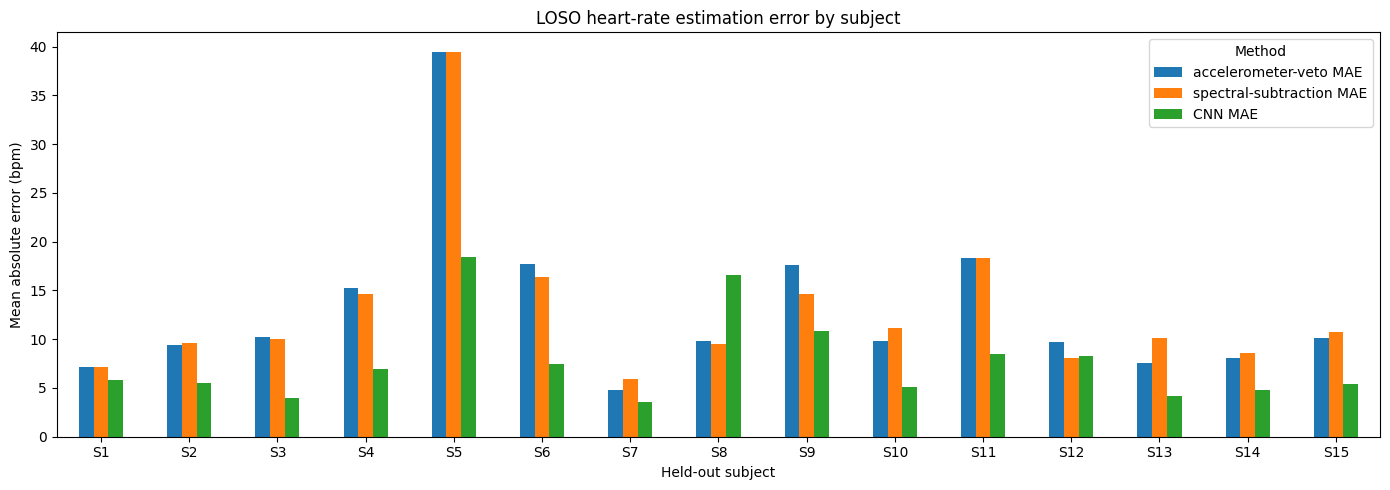

In [16]:
plot_data = comparison.set_index("subject")[
    ["accelerometer-veto MAE", "spectral-subtraction MAE", "CNN MAE"]
]

ax = plot_data.plot(kind="bar", figsize=(14, 5))
ax.set_xlabel("Held-out subject")
ax.set_ylabel("Mean absolute error (bpm)")
ax.set_title("LOSO heart-rate estimation error by subject")
ax.legend(title="Method")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Subject diagnostics

I compared CNN MAE with each subject's heart-rate distribution, PPG RMS amplitude, and high-pass accelerometer RMS amplitude to investigate why the error was concentrated in a small number of subjects.


In [17]:
def subject_diagnostics(subjects_dict):
    highpass_b, highpass_a = butter(2, 0.5, btype="highpass", fs=ACC_FS)
    rows = []

    for subject_id in sorted(subjects_dict, key=subject_sort_key):
        d = subjects_dict[subject_id]
        labels = np.asarray(d["label"], dtype=float)
        ppg = np.asarray(d["signal"]["wrist"]["BVP"], dtype=float).ravel()

        acceleration = np.asarray(d["signal"]["wrist"]["ACC"], dtype=float)
        acceleration_magnitude = np.linalg.norm(acceleration, axis=1)
        motion_component = filtfilt(highpass_b, highpass_a, acceleration_magnitude)

        rows.append(
            {
                "subject": subject_id,
                "mean HR": labels.mean(),
                "HR SD": labels.std(ddof=0),
                "PPG RMS amplitude": np.sqrt(np.mean(ppg ** 2)),
                "motion RMS amplitude": np.sqrt(np.mean(motion_component ** 2)),
                "CNN MAE": cnn_mae[subject_id],
            }
        )

    return pd.DataFrame(rows)

diagnostics = subject_diagnostics(subjects)
display(diagnostics.round(3))


,subject,mean HR,HR SD,PPG RMS amplitude,motion RMS amplitude,CNN MAE
0,S1,74.839,16.158,97.139,0.200,5.8
1,S2,82.486,13.738,37.960,0.176,5.5
2,S3,89.012,15.852,69.976,0.176,4.0
3,S4,87.899,12.980,59.747,0.191,6.9
4,S5,125.840,19.562,103.808,0.171,18.4
5,S6,119.490,22.318,83.514,0.193,7.5
6,S7,86.687,18.546,60.293,0.159,3.6
7,S8,74.267,11.871,53.658,0.176,16.6
8,S9,87.263,19.952,97.254,0.190,10.8
9,S10,87.516,15.713,58.701,0.175,5.1


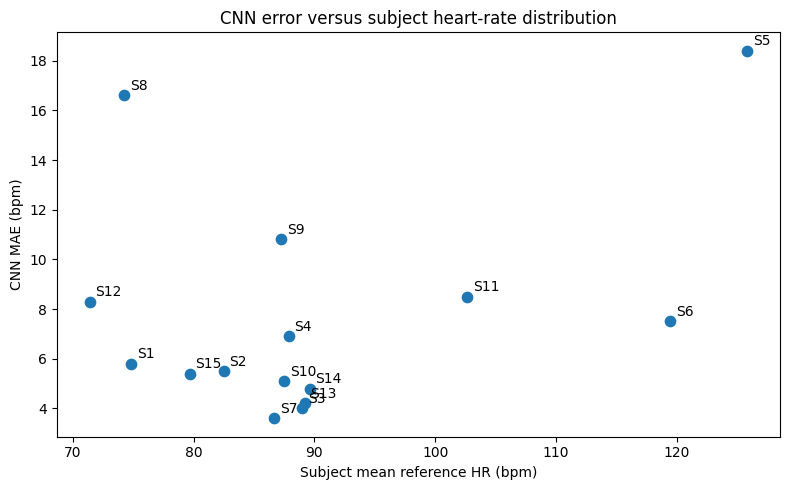

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(diagnostics["mean HR"], diagnostics["CNN MAE"], s=55)
for _, row in diagnostics.iterrows():
    plt.annotate(
        row["subject"],
        (row["mean HR"], row["CNN MAE"]),
        xytext=(4, 4),
        textcoords="offset points",
    )
plt.xlabel("Subject mean reference HR (bpm)")
plt.ylabel("CNN MAE (bpm)")
plt.title("CNN error versus subject heart-rate distribution")
plt.tight_layout()
plt.show()


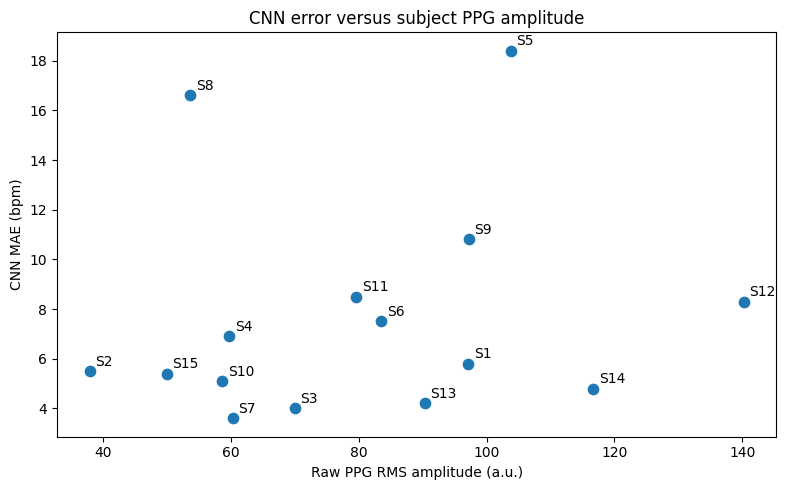

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(diagnostics["PPG RMS amplitude"], diagnostics["CNN MAE"], s=55)
for _, row in diagnostics.iterrows():
    plt.annotate(
        row["subject"],
        (row["PPG RMS amplitude"], row["CNN MAE"]),
        xytext=(4, 4),
        textcoords="offset points",
    )
plt.xlabel("Raw PPG RMS amplitude (a.u.)")
plt.ylabel("CNN MAE (bpm)")
plt.title("CNN error versus subject PPG amplitude")
plt.tight_layout()
plt.show()


## Limitations and conclusions

The CNN error was concentrated in four of the 15 subjects: S5 at 26.6 bpm, S9 at 11.9 bpm, S8 at 11.1 bpm, and S12 at 10.4 bpm, while 8 of the 15 subjects were below 7 bpm MAE. The subject-level diagnostics suggest that S5 was difficult partly because its reference heart-rate distribution was higher than most of the cohort, while S8 sat among the lowest PPG RMS amplitudes. Accelerometer RMS was more similar across subjects, so motion magnitude alone did not explain the high-error tail.

Overall, the two motion-aware spectral methods remained near 13 bpm mean subject MAE, while the 1D CNN reduced the error to 8.84 bpm under the same LOSO framework. The main remaining limitation is uneven cross-subject performance rather than average performance across the easier subjects.

The reference heart rate is itself derived from a chest ECG rather than measured beat by beat at the wrist, so label noise is present in both training and evaluation. Both classical grid searches saturated at an endpoint of their parameter range, which suggests the ranges were too narrow. Each fold was also run with a single seed, so the fold-level variance introduced by initialization is not quantified here.

### Reference

Reiss, A., Indlekofer, I., Schmidt, P., and Van Laerhoven, K. *Deep PPG: Large-Scale Heart Rate Estimation with Convolutional Neural Networks.* Sensors, 2019, 19(14), 3079.
